# Fake News Detection — Baseline Models
**Dataset:** Kaggle "Fake and Real News Dataset" (Bisaillon) — `Fake.csv` + `True.csv`



In [1]:
import re
import json
import pickle
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

%matplotlib inline


## 1. Load data


In [2]:
FAKE_PATH = "Fake.csv"
REAL_PATH = "True.csv"

fake = pd.read_csv(FAKE_PATH)
real = pd.read_csv(REAL_PATH)

fake["label"] = 1  # 1 = fake
real["label"] = 0  # 0 = real

print("Fake articles:", len(fake))
print("Real articles:", len(real))
fake.head(2)


Fake articles: 23481
Real articles: 21417


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1


## 2. Clean text

**Important:** the "real" articles are almost entirely Reuters wire copy, and the "fake" articles
almost entirely come from a small number of blog-style sites that embed "Featured image via Getty Images" captions
and video-embed boilerplate. If left in, a model can hit 99% accuracy by learning **which publisher wrote the
article** rather than learning genuine fake-vs-real content signal. This is a known issue with this dataset.

The cleaning function below strips:
- The Reuters dateline prefix (`"WASHINGTON (Reuters) - "`)
- URLs
- Explicit publisher/source artifacts (Reuters, Getty Images, Featured Image, social media boilerplate)

Even after this, some wire-service *style* conventions remain (e.g. "said," day-of-week words, "spokesman") —
this reflects a genuine difference between formal journalism and informal blog writing.

In [3]:
def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    # Remove Reuters-style dateline: CAPS LOCATION (Reuters) -
    text = re.sub(r"^[A-Z\s,]+\(Reuters\)\s*-\s*", "", text)
    # Remove URLs
    text = re.sub(r"http\S+|www\.\S+", "", text)

    # Publisher / source artifact removal (leakage prevention)
    artifact_patterns = [
        r"\breuters\b",
        r"\bgetty images?\b",
        r"\bfeatured image\b(\s+via\s+\S+)?",
        r"\bvia\s+(getty|afp|ap|shutterstock)\b",
        r"\bimage via\b",
        r"\b(twitter|facebook|youtube)\.com\S*",
        r"\bpic\.twitter\.com\S*",
        r"21st\s*century\s*wire",
        r"\bafp\b",
    ]
    for pattern in artifact_patterns:
        text = re.sub(pattern, " ", text, flags=re.IGNORECASE)

    text = re.sub(r"\s+", " ", text).strip()
    return text


df = pd.concat([fake, real], ignore_index=True)
df["title"] = df.get("title", "").fillna("")
df["text"] = df.get("text", "").fillna("")
df["full_text"] = (df["title"] + ". " + df["text"]).apply(clean_text)

df = df[df["full_text"].str.len() > 20]
df = df.drop_duplicates(subset="full_text").reset_index(drop=True)

print("Total articles after cleaning + dedup:", len(df))
df[["full_text", "label"]].head(3)


Total articles after cleaning + dedup: 39095


,full_text,label
0,Donald Trump Sends Out Embarrassing New Year’s...,1
1,Drunk Bragging Trump Staffer Started Russian C...,1
2,Sheriff David Clarke Becomes An Internet Joke ...,1


## 3. Exploratory Data Analysis

label
real    21195
fake    17900
Name: count, dtype: int64


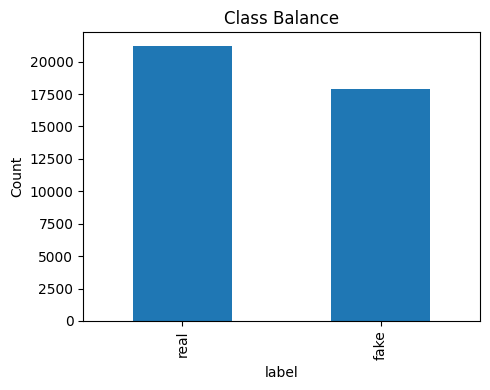

In [4]:
print(df["label"].value_counts().rename({0: "real", 1: "fake"}))

df["label"].value_counts().rename({0: "real", 1: "fake"}).plot(kind="bar", figsize=(5,4), title="Class Balance")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


         count        mean         std  min    25%    50%    75%     max
label                                                                   
0      21195.0  395.613447  273.564642  4.0  158.0  369.0  533.0  5180.0
1      17900.0  427.336480  356.625802  4.0  278.0  383.0  511.0  8141.0


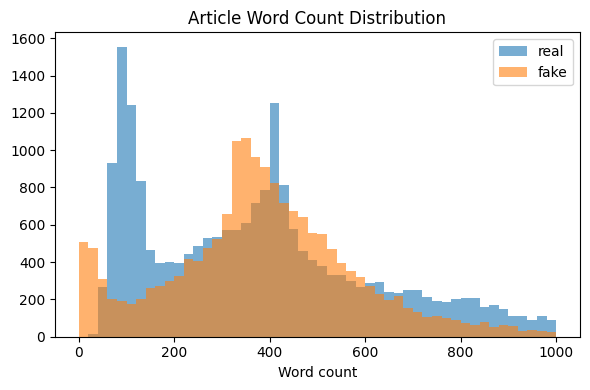

In [5]:
df["word_count"] = df["full_text"].str.split().apply(len)
print(df.groupby("label")["word_count"].describe())

plt.figure(figsize=(6,4))
for label, name in [(0, "real"), (1, "fake")]:
    subset = df[df["label"] == label]["word_count"]
    plt.hist(subset, bins=50, alpha=0.6, label=name, range=(0, 1000))
plt.legend()
plt.title("Article Word Count Distribution")
plt.xlabel("Word count")
plt.tight_layout()
plt.show()


## 4. TF-IDF features + train/test split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    df["full_text"], df["label"],
    test_size=0.2, random_state=42, stratify=df["label"]
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    stop_words="english",
    min_df=2
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
X_train_tfidf.shape


Train size: 31276, Test size: 7819


(31276, 20000)

## 5. Train baseline models

In [7]:
results = {}
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, C=1.0),
    "SVM (Linear)": LinearSVC(max_iter=5000)
}
trained_models = {}

for name, model in models.items():
    print(f"--- Training {name} ---")
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(classification_report(y_test, preds, target_names=["real", "fake"]))
    print()

    results[name] = {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}
    trained_models[name] = model

results


--- Training Logistic Regression ---


Accuracy:  0.9789
Precision: 0.9880
Recall:    0.9656
F1-score:  0.9767
              precision    recall  f1-score   support

        real       0.97      0.99      0.98      4239
        fake       0.99      0.97      0.98      3580

    accuracy                           0.98      7819
   macro avg       0.98      0.98      0.98      7819
weighted avg       0.98      0.98      0.98      7819


--- Training SVM (Linear) ---


Accuracy:  0.9873
Precision: 0.9907
Recall:    0.9816
F1-score:  0.9861
              precision    recall  f1-score   support

        real       0.98      0.99      0.99      4239
        fake       0.99      0.98      0.99      3580

    accuracy                           0.99      7819
   macro avg       0.99      0.99      0.99      7819
weighted avg       0.99      0.99      0.99      7819




{'Logistic Regression': {'accuracy': 0.9788975572323827,
  'precision': 0.9879965704486996,
  'recall': 0.9656424581005587,
  'f1': 0.9766916231106089},
 'SVM (Linear)': {'accuracy': 0.9873385343394296,
  'precision': 0.9906963631237665,
  'recall': 0.9815642458100559,
  'f1': 0.9861091623403957}}

## 6. Confusion matrices

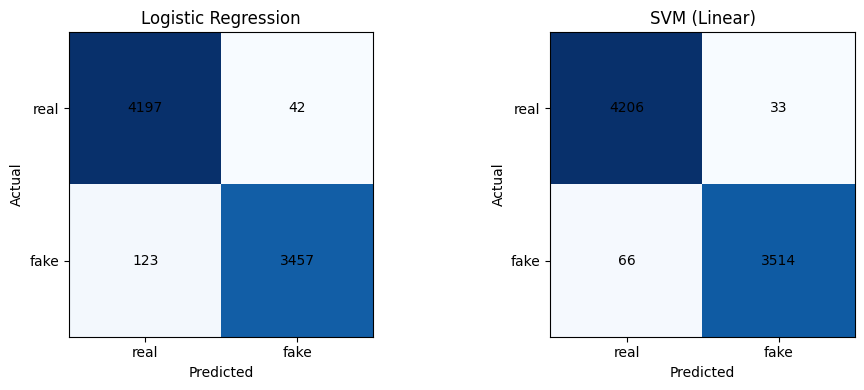

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, model) in zip(axes, trained_models.items()):
    preds = model.predict(X_test_tfidf)
    cm = confusion_matrix(y_test, preds)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(name)
    ax.set_xticks([0,1]); ax.set_xticklabels(["real","fake"])
    ax.set_yticks([0,1]); ax.set_yticklabels(["real","fake"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()


## 7. Target check (85% accuracy)

In [9]:
target_met = any(m["accuracy"] >= 0.85 for m in results.values())
print(f"85% accuracy target met: {target_met}")
for name, m in results.items():
    print(f"  {name}: accuracy={m['accuracy']:.4f}, f1={m['f1']:.4f}")


85% accuracy target met: True
  Logistic Regression: accuracy=0.9789, f1=0.9767
  SVM (Linear): accuracy=0.9873, f1=0.9861


## 8. Leakage check 



In [10]:
lr_model = trained_models["Logistic Regression"]
feature_names = np.array(vectorizer.get_feature_names_out())
coefs = lr_model.coef_[0]

top_fake_idx = np.argsort(coefs)[-15:][::-1]
top_real_idx = np.argsort(coefs)[:15]

print("Top features -> FAKE:")
for i in top_fake_idx:
    print(f"  {feature_names[i]:30s} {coefs[i]:.3f}")

print()
print("Top features -> REAL:")
for i in top_real_idx:
    print(f"  {feature_names[i]:30s} {coefs[i]:.3f}")


Top features -> FAKE:
  video                          9.985
  just                           8.091
  gop                            6.466
  read                           5.758
  hillary                        5.553
  president trump                5.106
  watch                          5.007
  pic                            4.804
  like                           4.591
  america                        4.526
  mr                             4.381
  obama                          4.102
  president obama                4.033
  breaking                       3.710
  isis                           3.690

Top features -> REAL:
  said                           -18.400
  washington                     -7.209
  president donald               -6.376
  wednesday                      -5.522
  tuesday                        -5.501
  thursday                       -4.942
  republican                     -4.897
  friday                         -4.370
  monday                         -3.975
  nov    

**Interpretation:** words like *said, washington, spokesman, told, reporters* (real) versus
*video, just, watch, breaking, really, actually* (fake) reflect a genuine but narrower distinction than
"true vs false" — closer to **formal wire-service journalism style vs informal blog/opinion style**. This is
a known characteristic of this dataset and it is a limitation: the baseline model is partly
learning genre/style, not purely truthfulness. 
